# GLASS Flows: Transition Sampling with Flow and Diffusion Models
### *A minimal implementation*

In this tutorial, I provide a minimal implementation of our work [GLASS Flows](https://arxiv.org/pdf/2509.25170). GLASS Flows is an ODE-based way of sampling stochastic Markov transitions in flow matching and diffusion models. You can think of GLASS Flows as *stochastic* flow matching or - in diffusion language - the *probability ODE* for SDEs. Here, I will focus on implementation. For a detailed description of method, I refer to our [GLASS Flows: Transition Sampling for Alignment of Flow and Diffusion Models](https://arxiv.org/pdf/2509.25170), in particular Algorithm 1 in the work.

In [1]:
import math
import time
import torch
from torch import nn, Tensor
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.transforms import Bbox

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

Some utility functions.

In [2]:
def format_batch_variable(t, x_t):
    t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)
    if t.ndim == 0:
        t = t.unsqueeze(0)
    if len(t) < x_t.shape[0]:
        assert len(t) == 1
        t = torch.ones(size=(x_t.shape[0],),device=x_t.device, dtype=x_t.dtype) * t
    return t

def mult_first_dim(x, t):
    if t.ndim == 0:
        return t * x
    # Ensure t is a 1D tensor
    t = t.view(-1)
    # Check if the first dimension of x matches the size of t
    if x.size(0) != t.size(0):
        raise ValueError("The size of the vector t must match the first dimension of tensor x.")
    # Reshape t to enable broadcasting along the other dimensions of x
    t = t.view(-1, *([1] * (x.dim() - 1)))
    # Multiply x by t using broadcasting
    result = x * t
    return result
    
def grab(x):
    return x.detach().cpu().numpy()

## 1. Define GLASS Flows class

We define `GlassFlow` class that takes in a pre-trained flow matching model `fm_model` and reparameterizes it to enable sampling GLASS Flow transition. Every flow matching model depends on schedulers $\alpha_t,\sigma_t$. Here, we assume that the schedulers for the pre-trained flow matching model are the [CondOT schedulers](https://arxiv.org/abs/2210.02747) (also called linear schedulers) given by $\alpha_t=t, \sigma_t=1-t$. For a different pre-trained model, one would need to change these schedulers and with that also the effective noise scale function $g_t$ and $g_t^{-1}$.

In [3]:
class GlassFlow(nn.Module):
    """A module that takes in a flow matching model and converts it into a posterior flow matching model"""
    def __init__(self,
                 fm_model: nn.Module,
                 clip_val: float = 1e-8,
                 t_min: float = 0.001,
                 t_max: float = 0.999,
                 eta_t_clip: float = 200.0,
                 ):
        """
        fm_model: a flow matching model that accepts an x_t and t arguments and returns a velocity
        """
        super().__init__()
        self.fm_model = fm_model
        self.clip_val = clip_val
        self.t_min = t_min
        self.t_max = t_max
        self.eta_t_clip = eta_t_clip

    #################################################
    # Functions that depend on scheduler of pre-trained model
    # ATTENTION: These functions might have to be changed for different 
    # flow matching/diffusion model
    ##################################################
    def alpha_t(self, t):
        return t

    def dot_alpha_t(self, t):
        return torch.ones_like(t)
        
    def sigma_t(self, t):
        return 1-t

    def dot_sigma_t(self, t):
        return -torch.ones_like(t)

    def g_t(self, t):
        return (self.sigma_t_start(t)/torch.clip(self.alpha_t_start(t),min=self.clip_val))**2
    
    def g_t_inv(self, inp_):
        return 1/(1+torch.sqrt(inp_))

    #################################################
    # GLASS Functions
    ##################################################
    def denoiser(self, x_t, t, **kwargs):
        t = format_batch_variable(t, x_t)
        velocity = self.fm_model(x_t=x_t,t=t, **kwargs)
        difference = mult_first_dim(velocity, self.sigma_t(t)) \
            - mult_first_dim(x_t, self.dot_sigma_t(t))
        denominator = self.dot_alpha_t(t) * self.sigma_t(t) - self.dot_sigma_t(t) * self.alpha_t(t)
        return mult_first_dim(difference, 1/torch.clip(denominator, min=self.clip_val))

    def bar_alpha_s(self, s: Tensor, bar_alpha_final: float):
        return bar_alpha_final*s

    def dot_bar_alpha_s(self, s: Tensor, bar_alpha_final: float):
         return bar_alpha_final*torch.ones_like(s)
        
    def bar_sigma_s(self, s: Tensor, sigma_cond_final: float):
        return s * sigma_cond_final + (1-s)

    def dot_bar_sigma_s(self, s: Tensor, sigma_cond_final: float):
        return torch.ones_like(s) * (sigma_cond_final - 1.0)
    
    def get_num_stable_inverse(self, matrix: Tensor):
        return torch.linalg.inv(matrix + 0.0001 * self.clip_val * torch.eye(matrix.shape[0], device=matrix.device, dtype=matrix.dtype))

    def get_glass_denoiser(self, mu_s: Tensor, Cov_s: Tensor, X_t: Tensor, bar_X_s: Tensor, dtype: torch.dtype, precdtype: torch.dtype, **kwargs):
        inv_Cov_s = self.get_num_stable_inverse(Cov_s)
        bproduct = mu_s @ inv_Cov_s @ mu_s
        t_star = self.g_t_inv(1/torch.clip(bproduct,min=self.clip_val))

        # Compute sufficient statistic:
        weights = self.alpha_t(t_star) * (mu_s @ inv_Cov_s)/torch.clip(bproduct,min=self.clip_val)
        scaled_suff_stat = weights[0] * X_t + weights[1] * bar_X_s

        # Get denoiser
        denoiser = self.denoiser(x_t=scaled_suff_stat.to(dtype), 
                                 t=t_star.to(dtype), 
                                 **kwargs).to(dtype=precdtype)
        return denoiser

        
    def sample_glass_transition(self,
                          X_t: Tensor, 
                          t_start: Tensor,
                          t_end: Tensor,
                          corr_rho: Tensor,
                          n_steps: int,
                          dtype: torch.dtype,
                          device: torch.device,
                          schedule: str = "s_linear",
                          return_traj: bool = False,
                          precdtype: torch.dtype = torch.float64,
                          **kwargs):

        # Get time steps:
        s_vec = torch.linspace(self.t_min, self.t_max, n_steps+1, dtype=precdtype, device=device)

        # Get mean and variance scales:
        alpha_t_start = self.alpha_t(t_start).to(precdtype)
        alpha_t_end = self.alpha_t(t_end).to(precdtype)
        sigma_t_start = self.sigma_t(t_start).to(precdtype)
        sigma_t_end = self.sigma_t(t_end).to(precdtype)

        # Initialization:
        bar_gamma = corr_rho * sigma_t_end/torch.clip(sigma_t_start, min=self.clip_val)
        bar_X_s_init = bar_gamma * X_t + torch.randn_like(X_t)


        # Conditional distribution:
        bar_alpha_final = alpha_t_end - bar_gamma * alpha_t_start
        bar_sigma_final = torch.sqrt(torch.clip((sigma_t_end**2) * (1-corr_rho**2),min=0.0))

        # Get schedulers for inner probability path:
        bar_alpha_s = self.bar_alpha_s(s_vec, bar_alpha_final)
        dot_bar_alpha_s = self.dot_bar_alpha_s(s_vec, bar_alpha_final)
        bar_sigma_s = self.bar_sigma_s(s_vec, bar_sigma_final)
        dot_bar_sigma_s = self.dot_bar_sigma_s(s_vec, bar_sigma_final)

        # Get weights:
        w_1 = dot_bar_sigma_s/torch.clip(bar_sigma_s,min=self.clip_val)
        w_2 = dot_bar_alpha_s - w_1 * bar_alpha_s
        w_3 = - w_1 * bar_gamma

        # Convert to higher precision:
        X_t = X_t.to(dtype=precdtype)

        # Initialize:
        bar_X_s = bar_X_s_init

        if return_traj:
            traj_list = [bar_X_s.cpu().detach().float()]

        n_steps = len(s_vec) - 1
        for i in range(n_steps):


            # Compute t_star:
            mu_s = torch.tensor([alpha_t_start, bar_alpha_s[i]+bar_gamma*alpha_t_start], dtype=precdtype, device=device)
            Cov_s = torch.tensor([[sigma_t_start**2, bar_gamma*(sigma_t_start**2)],
                                   [bar_gamma*(sigma_t_start**2), bar_sigma_s[i]**2 + (bar_gamma**2)*(sigma_t_start**2)]], 
                                    dtype=precdtype, device=device)
            
            glass_denoiser = self.get_glass_denoiser(
                                                    X_t=X_t, 
                                                    bar_X_s=bar_X_s,
                                                    mu_s=mu_s, 
                                                    Cov_s=Cov_s, 
                                                    dtype=dtype, 
                                                    precdtype=precdtype, 
                                                    **kwargs)

            # Get velocity:
            velocity = w_1[i] * bar_X_s + w_2[i] * glass_denoiser + w_3[i] * X_t

            # Take Euler step:
            s_curr = s_vec[i]
            s_next = s_vec[i+1]
            bar_X_s = bar_X_s + (s_next - s_curr) * velocity

            if return_traj:
                traj_list.append(bar_X_s.cpu().detach())
        
        if return_traj:
            return traj_list
        else:
            return bar_X_s

    #########################
    # Specific GLASS transition: DDPM transition
    ##########################
    def get_ddpm_corr(self, t_start, t_end):
        ddpm_corr = glass_flow.alpha_t(t_start)*glass_flow.sigma_t(t_end)\
            /torch.clip(glass_flow.alpha_t(t_end) * glass_flow.sigma_t(t_start),min=glass_flow.clip_val)
        return ddpm_corr

    def sample_glass_transition_ddpm(self, t_start, t_end, **kwargs):
        ddpm_corr = self.get_ddpm_corr(t_start, t_end)
        return self.sample_glass_transition(t_start=t_start, t_end=t_end, corr_rho=ddpm_corr, **kwargs)

# 2. Load pre-trained flow matching model

To use GLASS Flows, we need a pre-trained flow matching model. For simplicity, I just train one here from scratch. The below is a generic implementation of flow matching and just included here for completeness. 

As a dataset, I use a synthetic checkerboard dataset.

Text(0.5, 1.0, 'Dataset')

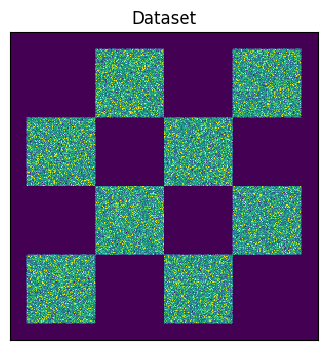

In [4]:
def inf_train_gen(batch_size: int = 200, device: str = "cpu"):
    x1 = torch.rand(batch_size, device=device) * 4 - 2
    x2_ = torch.rand(batch_size, device=device) - torch.randint(high=2, size=(batch_size, ), device=device) * 2
    x2 = x2_ + (torch.floor(x1) % 2)
    data = 1.0 * torch.cat([x1[:, None], x2[:, None]], dim=1) / 0.45
    
    return data.float()

def plot_emp_dist(samples, ax):
    H= ax.hist2d(samples[:,0], samples[:,1], 300, range=((-5,5), (-5,5)))
    cmax = np.percentile(H[0],99)
    cmin = 0.0
    norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)
    _ = ax.hist2d(samples[:,0], samples[:,1], 300, range=((-5,5), (-5,5)), norm=norm)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

VISUALIZATION_BATCH_SIZE = 300000
fig, ax = plt.subplots(figsize=(4,4))
samples = inf_train_gen(VISUALIZATION_BATCH_SIZE)
plot_emp_dist(samples, ax);
ax.set_title("Dataset")

To train a flow matching model on this dataset, we construct a simple multilayer perceptron (MLP) that represents the velocity field $u_t$.

In [5]:
class TimestepEmbedder(nn.Module):
    def __init__(self, dim, nfreq=256):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(nfreq, dim), nn.SiLU(), nn.Linear(dim, dim))
        self.nfreq = nfreq

    @staticmethod
    def timestep_embedding(t, dim, max_period=10000):
        half_dim = dim // 2
        freqs = torch.exp(
            -math.log(max_period)
            * torch.arange(start=0, end=half_dim, dtype=torch.float32)
            / half_dim
        ).to(device=t.device)
        args = t[:, None].float() * freqs[None]
        embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if dim % 2:
            embedding = torch.cat(
                [embedding, torch.zeros_like(embedding[:, :1])], dim=-1
            )
        return embedding

    def forward(self, t):
        t_freq = self.timestep_embedding(t, self.nfreq)
        t_emb = self.mlp(t_freq)
        return t_emb

# activation and model
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x): 
        return torch.sigmoid(x)*x

class Flow(nn.Module):
    def __init__(self,
                 input_dim=2,
                 time_emb_dim=16,
                 hidden_dim=128,
                 act=Swish(),
                 output_dim=2,
                 num_classes=None,
                 clip_val: float = 1e-8,
                 cfg_scale: float = 1.0
                 ):
        super().__init__()
        self.clip_val = clip_val
        self.input_dim = input_dim
        self.time_emb_dim = time_emb_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.act = act
        self.num_classes = num_classes
        self.cfg_scale = cfg_scale
        if num_classes is not None:
            raise NotImplementedError()
        self.t_emb = TimestepEmbedder(dim=time_emb_dim)

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_emb_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, output_dim),
            )

    def forward(self, x_t, t, extra={}):
        if "label" in extra:
            raise NotImplementedError()
        t_emb = self.t_emb(t.squeeze())
        h = torch.cat([x_t, t_emb], dim=1) # concat
        output = self.main(h) # forward
        return output
    
    def euler_step(self, x_t, t_start, t_next, extra={}):
        dt = t_next - t_start
        velocity = self.forward(x_t, t_start, extra=extra)
        x_next = x_t + velocity * dt[:,None]
        return x_next

In [6]:
N_EPOCHS = 50000
RETRAIN_FLOW = False # Whether to re-train or load the model

Let's train. You can also just load the pre-trained model from the github if you set `RETRAIN_FLOW=False`.

In [7]:
device = torch.device('cuda')
model = Flow().to(device)
if RETRAIN_FLOW:
    torch.set_grad_enabled(True)
    optimizer = torch.optim.Adam(model.parameters(), 0.001)
    loss_fn = nn.MSELoss()
    batch_size = 4096
    for epoch in range(N_EPOCHS):
        if epoch % 100 == 0:
            print(f"epoch: {epoch}")
        x_1 = inf_train_gen(batch_size).to(device)
        x_0 = torch.randn_like(x_1).to(device)
        t = torch.rand(len(x_1), 1).to(device)
        x_t = (1 - t) * x_0 + t * x_1
        dx_t = x_1 - x_0
        optimizer.zero_grad()
        loss_fn(model(t=t, x_t=x_t), dx_t).backward()
        optimizer.step()
    torch.save(model.state_dict(),"./models/fm_checkerboard.ckpt")
    torch.set_grad_enabled(False)
else:
    model.load_state_dict(torch.load("./models/fm_checkerboard.ckpt"))

To sanity check that we loaded the model correctly, let's sample by simulating the ODE:

/tmp/ipykernel_1068787/899490743.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)


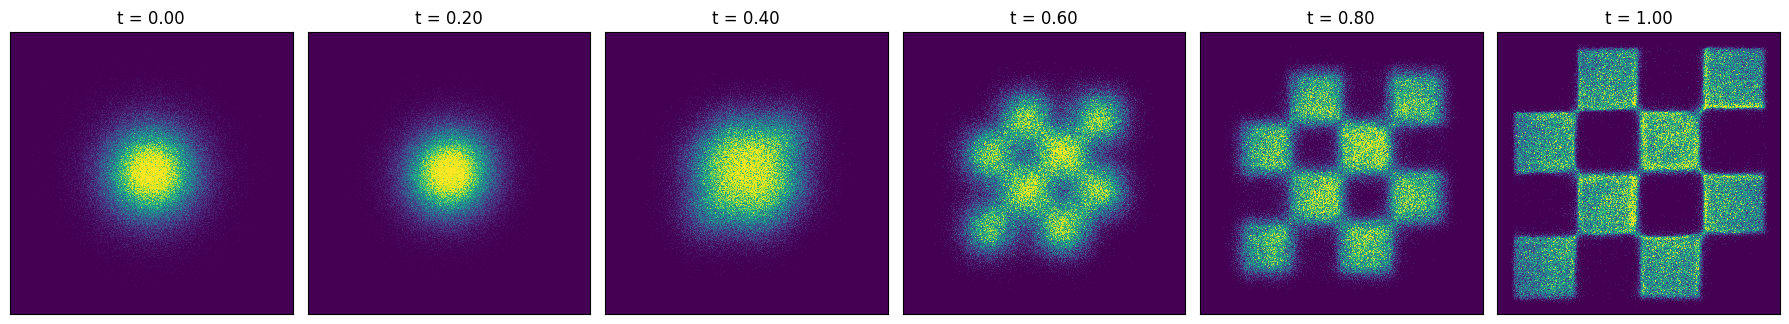

In [8]:
x = torch.randn(VISUALIZATION_BATCH_SIZE, 2).to(device)
n_steps = 20
n_plots = 6  # number of visualized timesteps
fig, axes = plt.subplots(1, n_plots, figsize=(18, 4), sharex=True, sharey=True)

time_steps = torch.linspace(0, 1.0, n_steps + 1).to(device)
# choose evenly spaced time indices to visualize
plot_indices = torch.linspace(0, n_steps, n_plots, dtype=torch.long)

plot_dict_flow = {}
plot_dict_flow[f'{0.0:.2f}'] = x.cpu()

with torch.no_grad():
    for i in range(n_steps):
        t_start = format_batch_variable(time_steps[i], x)
        t_next = format_batch_variable(time_steps[i + 1], x)
        x = model.euler_step(x_t=x, t_start=t_start, t_next=t_next).detach()

        # visualize if this step corresponds to one of our chosen times
        if (i + 1) in plot_indices:
            idx = (plot_indices == (i + 1)).nonzero(as_tuple=True)[0].item()
            plot_dict_flow[f'{time_steps[i + 1]:.2f}'] = x.cpu()

for idx, (time, x) in enumerate(plot_dict_flow.items()):
    plot_emp_dist(x.cpu(), axes[idx])
    axes[idx].set_title(f't = {time}')
    axes[idx].set_xlim(-5.0, 5.0)
    axes[idx].set_ylim(-5.0, 5.0)
    axes[idx].set_aspect('equal')

plt.tight_layout()
plt.show()


## 3. Create GLASS Flows model instance

We can now instantiate the GLASSFlow class.

In [9]:
glass_flow = GlassFlow(fm_model=model)

## 4. Sample from model using GLASS transitions

Let us now sample using GLASS transitions. We set $6$ transitions, i.e. grid points $\{0,0.2,0.4,0.6,0.8,1.0\}$. Between each grid point, we sample a GLASS transition. Our theory would predict that we recover the exact same marginals as the flow matching model. As you can see, this is indeed the case!

/tmp/ipykernel_1068787/899490743.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)


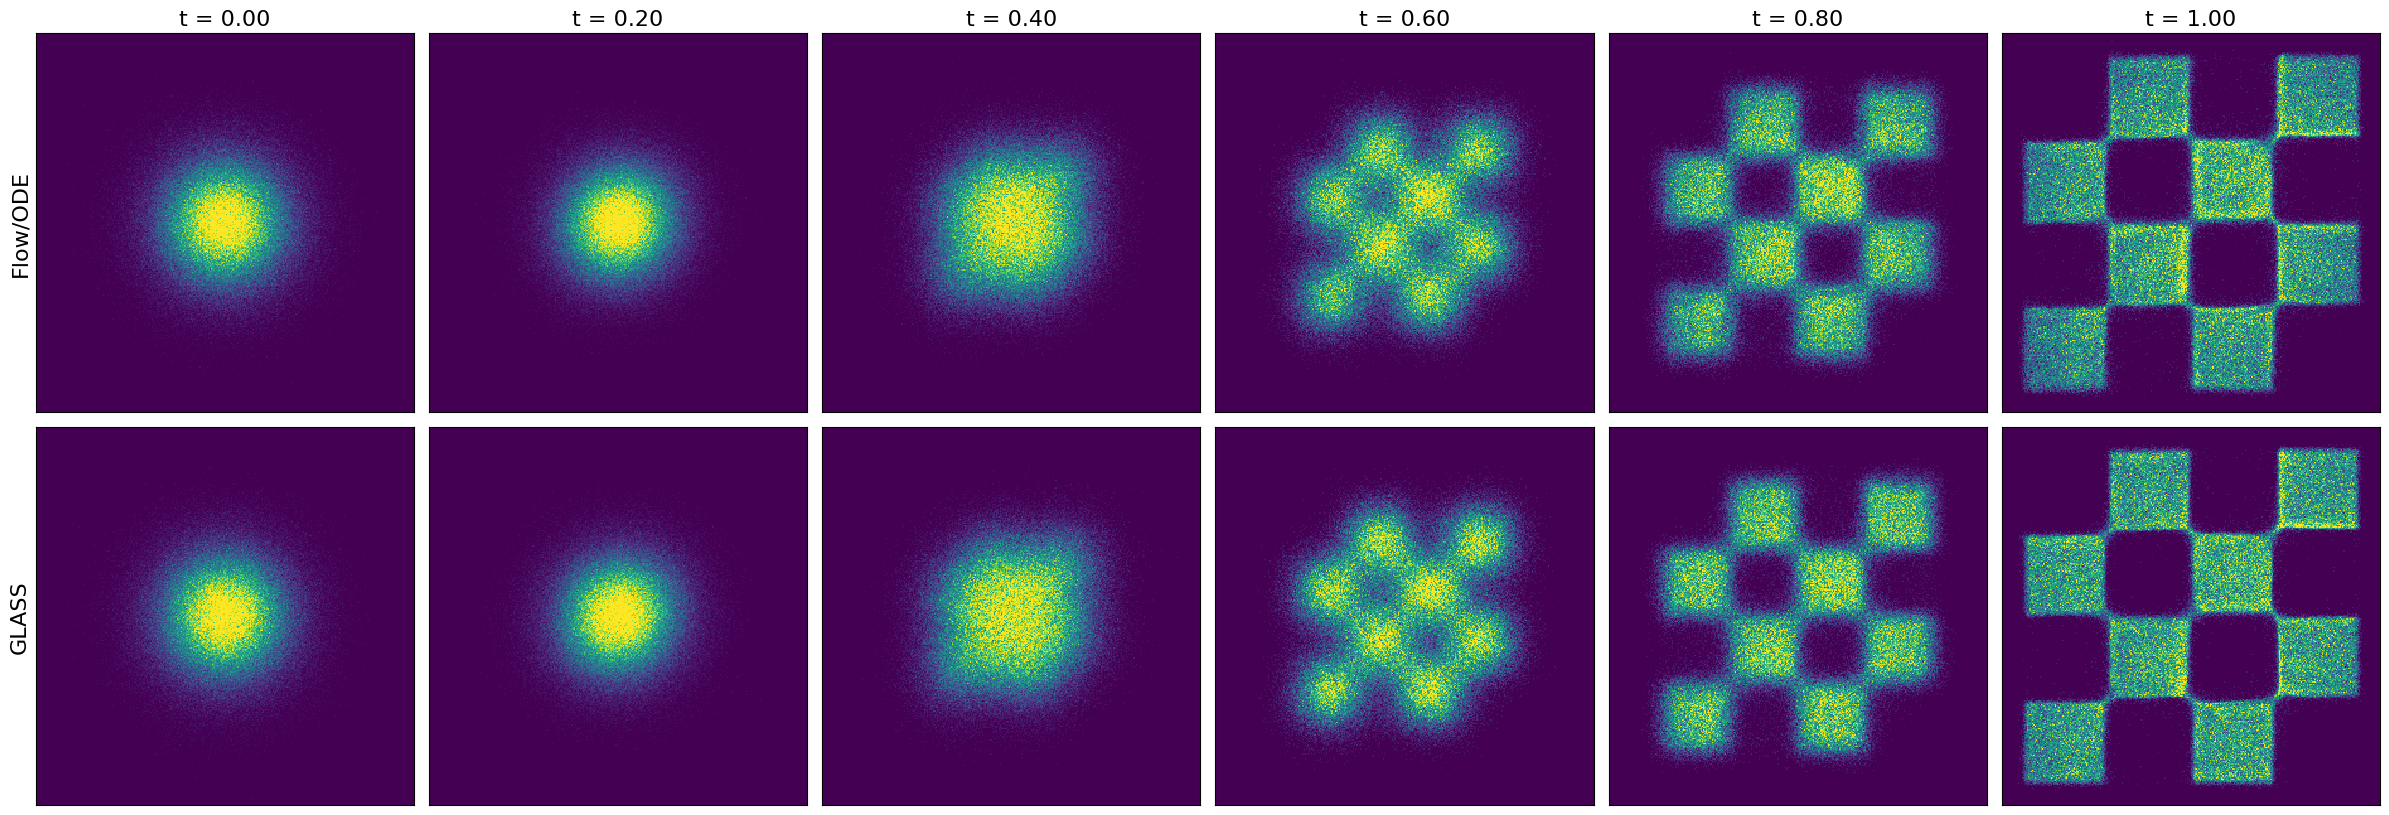

In [10]:
n_transitions = 6
t_backbone = torch.linspace(0,1,n_transitions)
batch_size = 300000
fontsize=16
plot_dict_glass = {}
X = torch.randn(size=(batch_size,2), device=device)
plot_dict_glass[f'{0.0:.2f}'] = X.cpu()
for idx in range(n_transitions-1):
    t_start = t_backbone[idx]
    t_end = t_backbone[idx+1]
    X = glass_flow.sample_glass_transition(
          X_t=X, 
          n_steps=10,
          t_start=t_start,
          t_end=t_end,
          corr_rho=0.4,
          dtype=torch.float32,
          device=device,
          precdtype=torch.float32)
    plot_dict_glass[f'{t_end:.2f}'] = X.cpu()

    
plt.show()

fig, axes = plt.subplots(2, n_transitions, figsize=(4*n_transitions, 2.10*4), sharex=True, sharey=True)
# plot_emp_dist(X.cpu(),axes[0])
# axes[0,].set_title(f't = {t_end:.2f}')

for idx, (time, x) in enumerate(plot_dict_flow.items()):
    plot_emp_dist(x.cpu(), axes[0, idx])
    axes[0, idx].set_title(f't = {time}',fontsize=fontsize)
    axes[0, idx].set_xlim(-5.0, 5.0)
    axes[0, idx].set_ylim(-5.0, 5.0)
    axes[0, idx].set_aspect('equal')

axes[0, 0].set_ylabel("Flow/ODE", fontsize=fontsize)

for idx, (time, x) in enumerate(plot_dict_glass.items()):
    plot_emp_dist(x.cpu(), axes[1, idx])
    axes[1, idx].set_xlim(-5.0, 5.0)
    axes[1, idx].set_ylim(-5.0, 5.0)
    axes[1, idx].set_aspect('equal')

axes[1, 0].set_ylabel("GLASS", fontsize=fontsize)

plt.tight_layout()
plt.savefig("figures/flow_and_glass_marginals.pdf")
plt.show()

## 5. Visualize stochastic transitions

While the marginal distribution are the same, GLASS transitions have stochastic transitions that we can visualize. Below, we sample from the GLASS transition
$$x_{t'}\sim p_{t'|t}(x_{t'}|x_{t})$$
We set the initial time $t=0.6$ and the time we transition to $t'=0.8$. Each row corresponds to a different initial point $x_t$. Each column corresponds to a different transition defined by the correlation parameter $\rho$. The correlation parameter allows us to control the "width" of the transition, i.e. how "close" $x_{t'}$ is to $x_{t}$.

/tmp/ipykernel_1068787/899490743.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)


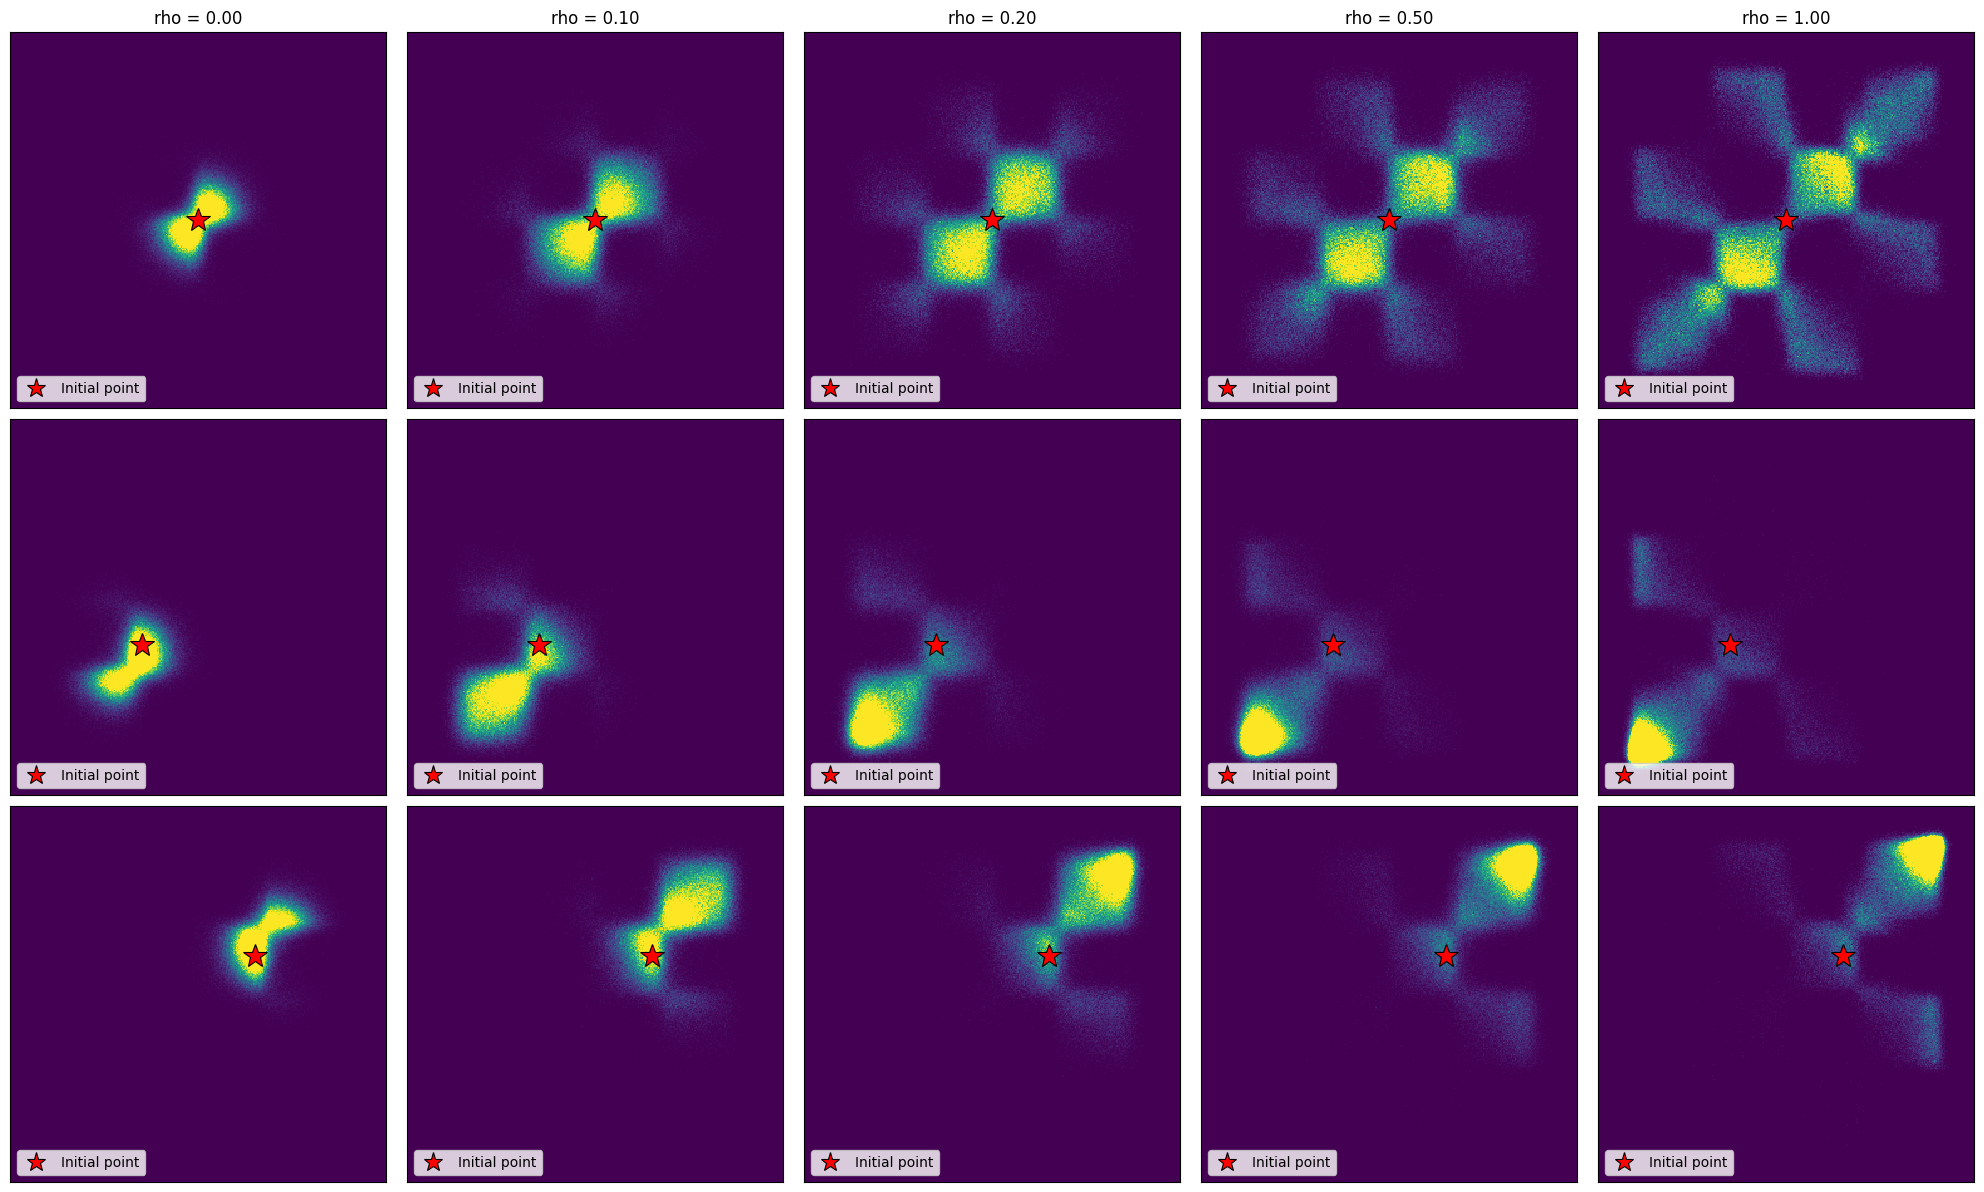

In [11]:
from matplotlib.lines import Line2D

# ---- Hand-pick your 3 start points inside [-2, 2] x [-2, 2] ----
X_start_list = [
    torch.tensor([  0.0,   0.0], device=device),
    torch.tensor([ -1.5,  -1.0], device=device),
    torch.tensor([  1.5,   1.0], device=device),
]
n_rows = len(X_start_list)

batch_size = 300000
t_start = torch.tensor(0.6, device=device)
t_end   = torch.tensor(0.8, device=device)

corr_rho_list = [0.0, 0.1, 0.2, 0.5, 1.0]
n_transitions = len(corr_rho_list)

# Create subplots: one row per X_start, one column per corr_rho
fig, axes = plt.subplots(
    n_rows, n_transitions, figsize=(4*len(corr_rho_list), n_rows*4),
    sharex=True, sharey=True
)

if n_rows == 1:
    axes = axes.unsqueeze(0)

# Create a reusable legend handle for the red star
star_handle = Line2D(
    [0], [0],
    marker='*', color='red',
    markeredgecolor='black', markeredgewidth=0.8,
    markersize=14, linestyle='None',
    label='Initial point'
)

# Loop over rows (different X_start) and columns (different corr_rho)
for row_idx, X_start in enumerate(X_start_list):
    X0 = X_start
    X  = torch.stack([X0] * batch_size)

    for col_idx, corr_rho in enumerate(corr_rho_list):
        X = glass_flow.sample_glass_transition(
            X_t=X,
            n_steps=30,
            t_start=t_start,
            t_end=t_end,
            corr_rho=corr_rho,
            dtype=torch.float32,
            device=device,
            precdtype=torch.float32
        )

        ax = axes[row_idx, col_idx]
        plot_emp_dist(X.detach().cpu(), ax)

        # Add big red star at the start point
        ax.plot(
            X0[0].item(), X0[1].item(),
            marker='*', markersize=18, linestyle='None',
            color='red', markeredgecolor='black', markeredgewidth=0.8
        )

        # Add legend (lower-left corner to avoid overlapping)
        ax.legend(
            handles=[star_handle],
            loc='lower left', fontsize=10,
            frameon=True, framealpha=0.8
        )

        if row_idx == 0:
            ax.set_title(f"rho = {corr_rho:.2f}", fontsize=12)

        ax.set_xlim(-5.0, 5.0)
        ax.set_ylim(-5.0, 5.0)
        ax.set_aspect('equal')

plt.tight_layout()
plt.savefig("./figures/varying_correlation_parameter.pdf", dpi=300)
plt.show()

Next, we visualize the transition via a hierarchical tree that represents the transitions.

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.collections import LineCollection

ref_samples = inf_train_gen(VISUALIZATION_BATCH_SIZE)


# =========================
# Branching with per-level k
# =========================
@torch.no_grad()
def sample_branching_2d_by_tlist(
    glass_flow,
    X_start: torch.Tensor,
    t_list,                         # e.g. [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    branch_factors=3,               # int OR list of length len(t_list)-1
    *,
    n_steps: int = 30,
    device=None,
    dtype=torch.float32,
    precdtype=torch.float32,
    corr_rho=0.5,                   # (kept for API compatibility; unused here)
):
    """
    Builds a branching tree in 2D with levels aligned to t_list.
    levels[l] are points at time t_list[l].
    For each level l -> l+1, we sample children via (t_start=t_list[l], t_end=t_list[l+1]).

    Returns:
        levels:              list of tensors; levels[l] shape (prod_k_up_to_l, 2), with levels[0]=(1,2)
        children_by_parent:  list of tensors per level; each has shape (n_parents_at_l, k_l, 2)
    """
    # Basic checks
    assert len(t_list) >= 2, "t_list must have at least two entries."
    assert all(t_list[i] <= t_list[i+1] for i in range(len(t_list)-1)), "t_list must be non-decreasing."

    # Normalize branch_factors to list per transition
    if isinstance(branch_factors, (int, float)):
        k_list = [int(branch_factors)] * (len(t_list) - 1)
    else:
        assert len(branch_factors) == len(t_list) - 1, \
            "branch_factors must be length len(t_list)-1."
        k_list = [int(k) for k in branch_factors]
        assert all(k >= 1 for k in k_list), "All branch factors must be >= 1."

    X0 = X_start.to(device=device, dtype=dtype).view(1, -1)  # (1, 2)
    levels = [X0]                 # level 0 at t_list[0]
    children_by_parent = []       # per level l: (n_parents, k_l, 2)

    for l in range(len(t_list) - 1):
        parents = levels[-1]                # (n_parents, 2)
        n_parents = parents.shape[0]
        k = k_list[l]

        # Repeat each parent k times → sample all children at once
        X_in = parents.repeat_interleave(k, dim=0)  # (n_parents*k, 2)

        t_start = torch.tensor(t_list[l],   device=device, dtype=dtype)
        t_end   = torch.tensor(t_list[l+1], device=device, dtype=dtype)

        X_out = glass_flow.sample_glass_transition_ddpm(
            X_t=X_in,
            n_steps=n_steps,
            t_start=t_start,
            t_end=t_end,
            dtype=dtype,
            device=device,
            precdtype=precdtype,
        )  # (n_parents*k, 2)

        children = X_out.view(n_parents, k, -1)     # (n_parents, k, 2)
        children_by_parent.append(children)
        levels.append(children.reshape(-1, 2))      # (n_parents*k, 2)

    return levels, children_by_parent


# =========================
# Plot (static) — unchanged
# =========================
def plot_branching_2d(
    levels, children_by_parent,
    *,
    node_ms=8, edge_lw=0.8, edge_alpha=0.6,
    show_root_star=True, title=None
):
    fig, ax = plt.subplots(figsize=(7.5, 7.5))

    # Draw edges
    for l in range(len(children_by_parent)):
        parents = levels[l]                  # (n_parents, 2)
        children = children_by_parent[l]     # (n_parents, k, 2)
        for i in range(parents.shape[0]):
            p = parents[i]
            C = children[i]                  # (k, 2)
            for j in range(C.shape[0]):
                ax.plot([p[0].item(), C[j, 0].item()],
                        [p[1].item(), C[j, 1].item()],
                        '-', linewidth=edge_lw, alpha=edge_alpha, color='black')

    # Draw nodes
    if show_root_star:
        root = levels[0][0]
        ax.plot(root[0].item(), root[1].item(),
                marker='*', markersize=18, linestyle='None',
                color='red', markeredgecolor='black', markeredgewidth=0.8,
                label='Initial point')

    for l in range(1, len(levels)):
        L = levels[l].detach().cpu()
        ax.plot(L[:, 0], L[:, 1], 'o', markersize=node_ms, color='black')

    # Bounds
    all_pts = torch.cat([lvl.detach().cpu() for lvl in levels], dim=0)
    xmin, ymin = all_pts.min(dim=0).values.tolist()
    xmax, ymax = all_pts.max(dim=0).values.tolist()
    dx, dy = xmax - xmin, ymax - ymin
    pad = 0.08 * max(dx if dx > 0 else 1.0, dy if dy > 0 else 1.0)
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)

    ax.set_aspect('equal', adjustable='box')
    if show_root_star:
        ax.legend(loc='upper right', frameon=True, framealpha=0.9)
    if title:
        ax.set_title(title, fontsize=14, pad=8)
    ax.grid(False)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    plt.tight_layout()
    plt.show()


# =========================
# Animation (GIF)
# =========================
def _adjust_bounds_square(ax, points, pad=0.08):
    points = np.asarray(points)
    x_min, x_max = points[:, 0].min(), points[:, 0].max()
    y_min, y_max = points[:, 1].min(), points[:, 1].max()
    cx, cy = (x_max + x_min)/2, (y_max + y_min)/2
    half = max(x_max - x_min, y_max - y_min) / 2
    half *= 1 + pad
    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy - half, cy + half)
    ax.set_aspect('equal')


# =========================
# Example usage
# =========================
# Times & per-transition branching
t_list = [0.0, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]   # 8 levels -> 7 transitions
branch_factors = [5, 4, 4, 3, 3, 2, 2]              # control k per transition

X_start = torch.tensor([0.0, 0.0], device=device)
n_steps = 30

levels, children_by_parent = sample_branching_2d_by_tlist(
    glass_flow=glass_flow,
    X_start=X_start,
    t_list=t_list,
    branch_factors=branch_factors,   # <— NEW
    n_steps=n_steps,
    device=device,
    dtype=torch.float32,
    precdtype=torch.float32,
)


def animate_branching_tree(
    levels, children_by_parent,
    *,
    t_list,                    # <— NEW: needed to display t_start -> t_end
    out_path="branching.gif",
    fps=30,
    start_pause_s=0.6,         # initial pause (only root shown)
    per_layer_hold_s=0.0,      # optional small hold after revealing each new layer
    end_pause_s=1.2,           # final pause after everything is shown
    node_ms=26,
    edge_lw=1.2,
    edge_alpha=0.7,
    show_root_star=True,
    dpi_save=150,
    title="Branching in 2D over time",
    show_transition_label=True,    # <— NEW
    label_fmt="{:.2f}",            # <— NEW: format for times
):
    """
    Animation timeline:
      (A) Start pause: only root (star) shown.
      (B) For l = 1..L: reveal edges(level l-1 -> l) + nodes at level l:
              - newly revealed nodes at level l are RED
              - previous (already revealed) nodes become BLACK
              - top-right annotation: "transition t_start -> t_end"
      (C) Leaf-only snapshot: hide all edges and intermediate nodes; show ONLY last level nodes in RED
      (D) Add ref_samples via plot_emp_dist(ref_samples, ax)
      (E) End pause
    """
    # Coerce to numpy for bounds and fast drawing
    levels_np = [lvl.detach().cpu().numpy() for lvl in levels]
    L = len(levels_np) - 1  # number of transitions / non-root levels
    assert len(t_list) == L + 1, "t_list length must be number of levels (len(levels))."

    # Precompute bounds over ALL points so the view doesn't jump
    all_pts = np.vstack(levels_np)
    fig, ax = plt.subplots(figsize=(6.8, 6.8))
    _adjust_bounds_square(ax, all_pts, pad=0.10)
    ax.grid(False)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(1.0); spine.set_color('gray'); spine.set_alpha(0.5)
    if title:
        ax.set_title(title, fontsize=14, pad=8)

    # -------------------
    # Pre-create artists
    # -------------------
    artists = []

    # Root star
    root = levels_np[0][0]
    root_star, = ax.plot(
        root[0], root[1], marker='*', markersize=16,
        linestyle='None', color='red',
        markeredgecolor='black', markeredgewidth=0.8,
        zorder=5, visible=show_root_star
    )
    artists.append(root_star)

    # Scatter for each level in BLACK (previously revealed nodes)
    level_scats_black = []
    for l in range(1, L + 1):
        pts = levels_np[l]
        sc = ax.scatter(pts[:, 0], pts[:, 1],
                        c='black', s=node_ms, zorder=4, alpha=0.95,
                        visible=False)
        level_scats_black.append(sc)
        artists.append(sc)

    # Scatter for current/new level in RED (one per level)
    level_scats_red = []
    for l in range(1, L + 1):
        pts = levels_np[l]
        sc = ax.scatter(pts[:, 0], pts[:, 1],
                        c='red', s=node_ms, zorder=5, alpha=0.95,
                        visible=False)
        level_scats_red.append(sc)
        artists.append(sc)

    # LineCollection for edges of each transition level
    edge_collections = []
    for l in range(L):
        parents = levels_np[l]            # (nP, 2)
        children = children_by_parent[l]  # (nP, k, 2) — still torch, make numpy
        children_np = children.detach().cpu().numpy()
        segs = []
        for i in range(parents.shape[0]):
            p = parents[i]
            C = children_np[i]  # (k, 2)
            for j in range(C.shape[0]):
                segs.append([[p[0], p[1]], [C[j, 0], C[j, 1]]])
        lc = LineCollection(
            segs,
            colors='black',
            linewidths=edge_lw,
            alpha=edge_alpha,
            zorder=2,
        )
        lc.set_visible(False)
        ax.add_collection(lc)
        edge_collections.append(lc)
        artists.append(lc)

    # Top-right transition label
    if show_transition_label:
        transition_txt = ax.text(
            0.98, 0.98, "", transform=ax.transAxes,
            ha="right", va="top", color="black", fontsize=12
        )
        artists.append(transition_txt)
    else:
        transition_txt = None

    # A handle we’ll use to add ref_samples at the very end
    ref_drawn = {"done": False}

    # -------------------
    # Framing schedule
    # -------------------
    start_pause_f = int(round(start_pause_s * fps))
    per_layer_hold_f = int(round(per_layer_hold_s * fps))
    end_pause_f = int(round(end_pause_s * fps))

    # frames:
    #   [0 .. start_pause_f-1]        -> start pause
    #   next L frames (one per level) -> reveal levels
    #   + per_layer_hold_f after each reveal (optional)
    #   + 1 frame                     -> leaf-only (no edges, only last level red)
    #   + 1 frame                     -> add ref_samples overlay
    #   + end_pause_f frames          -> end pause
    reveal_frames = []
    f = start_pause_f
    for l in range(1, L + 1):
        reveal_frames.append(f)   # frame where level l appears
        f += 1 + per_layer_hold_f
    leaf_only_frame = f; f += 1
    refs_frame = f; f += 1
    total_frames = f + end_pause_f

    # -------------------
    # Update / init
    # -------------------
    def init_func():
        # hide everything except root star
        for sc in level_scats_black + level_scats_red:
            sc.set_visible(False)
        for lc in edge_collections:
            lc.set_visible(False)
        if transition_txt is not None:
            transition_txt.set_text("")
        return tuple(artists)

    def _set_visibility_up_to_level(k):
        """
        k = 0: only root
        k >= 1: edges 0..k-1 visible; level k red; previous levels black
        """
        # edges
        for idx, lc in enumerate(edge_collections):
            lc.set_visible(idx < k)

        # nodes
        for l in range(1, L + 1):
            is_current = (l == k)
            level_scats_red[l-1].set_visible(is_current)   # current level red
            level_scats_black[l-1].set_visible(l < k)      # previous levels black

        # transition label
        if transition_txt is not None:
            if k >= 1:
                t0 = label_fmt.format(t_list[k-1])
                t1 = label_fmt.format(t_list[k])
                transition_txt.set_text(f"transition {t0} → {t1}")
            else:
                transition_txt.set_text("")

    def update(frame):
        # Phase A: start pause
        if frame < start_pause_f:
            _set_visibility_up_to_level(0)
            return tuple(artists)

        # Phase B: revealing levels one-by-one
        k = 0
        for idx, rf in enumerate(reveal_frames, start=1):
            if frame >= rf:
                k = idx
        if frame < leaf_only_frame:
            _set_visibility_up_to_level(k)
            return tuple(artists)

        # Phase C: leaf-only snapshot (no edges, only last level red)
        if frame == leaf_only_frame:
            for lc in edge_collections:
                lc.set_visible(False)
            for l in range(1, L):
                level_scats_black[l-1].set_visible(False)
                level_scats_red[l-1].set_visible(False)
            level_scats_black[-1].set_visible(False)
            level_scats_red[-1].set_visible(True)
            if transition_txt is not None:
                transition_txt.set_text("")   # hide label after reveal phase
            return tuple(artists)

        # Phase D: add ref_samples overlay once
        if frame == refs_frame and not ref_drawn["done"]:
            plot_emp_dist(ref_samples, ax)
            ref_drawn["done"] = True
            return tuple(artists)

        # (axes locks if you need them)
        ax.set_xlim(-5.0, 5.0)
        ax.set_ylim(-5.0, 5.0)
        ax.set_aspect('equal')

        # Phase E: end pause → keep what we have
        return tuple(artists)

    anim = FuncAnimation(
        fig, update, init_func=init_func,
        frames=total_frames, interval=1000/fps, blit=False, repeat=True
    )

    writer = PillowWriter(fps=fps, metadata={'loop': 0})
    anim.save(out_path, writer=writer, dpi=dpi_save)
    plt.close(fig)
    return out_path


gif_path = animate_branching_tree(
    levels, children_by_parent,
    t_list=t_list,                    # <— NEW
    out_path="figures/branching_tree.gif",
    fps=30,
    start_pause_s=0.7,
    per_layer_hold_s=0.7,
    end_pause_s=1.9,
    node_ms=26,
    edge_lw=1.2,
    edge_alpha=0.7,
    title="",
    show_transition_label=True,       # can toggle off
    label_fmt="{:.2f}",               # try "{:.3f}" if you want more precision
)


/tmp/ipykernel_1068787/899490743.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)


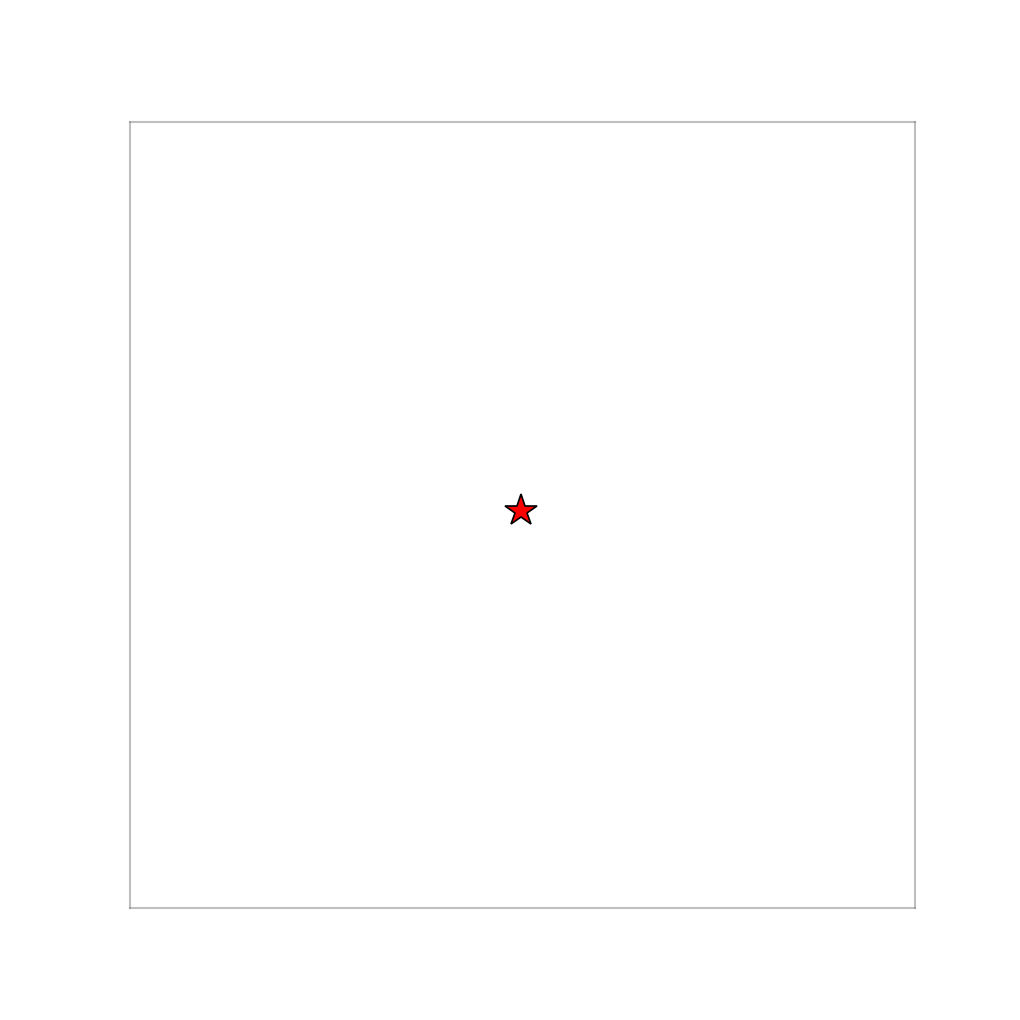

In [13]:
from IPython.display import Image
Image(filename="figures/branching_tree.gif")